Global Trade Horizons 2030: Predictive Modelling & Trend Analysis of International Exports

In [1]:
# installing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
!pip install xlrd 
from statsmodels.stats.diagnostic import het_breuschpagan

In [2]:
# creating the dataframe
df = pd.read_csv(r"C:\Users\Kanak Nath\Downloads\wb_exportdata_2025.csv")

# update existing DataFrame directly to replace empty cells with NaN
df.fillna(np.nan, inplace=True)

# cleaning up
df.columns = df.columns.str.strip()
df = df.drop(columns=['Country Code', 'Indicator Name', 'Indicator Code'])
print(df.head())

                  Country Name         1960         1961        1962  \
0                        Aruba          NaN          NaN         NaN   
1  Africa Eastern and Southern          NaN          NaN         NaN   
2                  Afghanistan  22222233.33  24444455.56  26666680.0   
3   Africa Western and Central          NaN          NaN         NaN   
4                       Angola          NaN          NaN         NaN   

          1963         1964         1965         1966         1967  \
0          NaN          NaN          NaN          NaN          NaN   
1          NaN          NaN          NaN          NaN          NaN   
2  68888922.22  71111144.44  113333340.0  120000000.0  113333340.0   
3          NaN          NaN          NaN          NaN          NaN   
4          NaN          NaN          NaN          NaN          NaN   

          1968  ...          2016          2017          2018          2019  \
0          NaN  ...  2.057715e+09  2.153472e+09  2.241203e+09  2.23

In [3]:
# MODEL 1: Log-linear 


# we can just change the country name to whichever country's information we want
country_name = input("Enter the Country Name to forecast: ")
country_data = df[df['Country Name'] == country_name].squeeze()

# finding out the time-series data
# only years are integer, so we'll condition that
years_str = [i for i in df.columns if i.isnumeric()]
ts_data = country_data[years_str].astype(float) # to convert the datatype to float

# interpolation
# back-fills if the very first years are missing
# forward-fills if the most recent years are missing
ts_clean = ts_data.interpolate(method = 'linear').bfill().ffill()

# convert the index to integers for the X-axis and scale the Y-axis
years = ts_clean.index.astype(int).values
exports_billions = ts_clean.values/1e9  # maths equivalent: 1 × 10⁹

# verification
print(pd.Series(exports_billions, index=years).head(10)) # pd.series is used to fuse two lists back together

Enter the Country Name to forecast:  India


1960    1.652702
1961    1.688402
1962    1.757702
1963    2.072702
1964    2.104202
1965    1.969802
1966    1.888226
1967    2.022667
1968    2.144000
1969    2.170667
dtype: float64


- creating the base for the actual model now
- this is what we want our model to look like

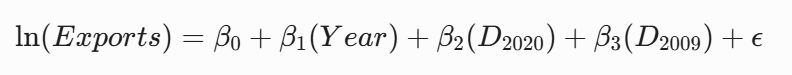

In [4]:
# setting up the equation
Y_log = np.log(exports_billions)
dummy_2020 = (years==2020).astype(int)
dummy_2009 = (years==2009).astype(int)

# RHS of the equation
X = np.column_stack([years, dummy_2020, dummy_2009])
X = sm.add_constant(X)

In [5]:
# modelling
model1 = sm.OLS(Y_log, X).fit()  # fitting
summary1 = model1.summary()  # summary
print("Regression Table:", summary1)

Regression Table:                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.985
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     1401.
Date:                Wed, 12 Aug 2026   Prob (F-statistic):           6.91e-57
Time:                        16:36:33   Log-Likelihood:                -1.5983
No. Observations:                  66   AIC:                             11.20
Df Residuals:                      62   BIC:                             19.96
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -210.0774      3.367  

In [6]:
# extract DB d-test and we'll come back to residual diagnostics later on
from statsmodels.stats.stattools import durbin_watson
dw_stat_model1 = durbin_watson(model1.resid)
print(f"The Durbin-Watson statistic for model 1 is : {dw_stat_model1}")

# DW test stat is near 0, which is pretty common in time-series data ( cuz autocorrelation, duh), we'll come back to this in the residual diagnostics section
# however, we can't just depend on OLS na, so we'll carry out another test for autocorrelation, just for verification
# until then, bbyee!!

The Durbin-Watson statistic for model 1 is : 0.2451759728055458


In [7]:
# forecasting for 2030 now
# the input for 2030 must match teh structure of X i.e. [constant, year, dummy_2020, dummy_2009]
X_2030 = [1,2030,0,0] # assuming 2030 is a normal year, the dummies have been set to zero

prediction1 = model1.get_prediction(X_2030)
# .predict() only returns simple point predictions, .get_prediction() returns advanced statistical metadata.
# like prediction variances, CIs, prediction intervals etc.

summary_frame = prediction1.summary_frame(alpha=0.05)  # alpha for CIs yaaar
print(summary_frame)
# converts metrics into a pandas framework, which makes it easier for analysis, exporting, plotting whatev

       mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  7.564142  0.072037       7.420142       7.708142      7.032966   

   obs_ci_upper  
0      8.095318  


In [8]:
# extracting the log values to finally present the answer
pred_log = summary_frame['mean'][0]
ci_lower_log = summary_frame['mean_ci_lower'][0]
ci_upper_log = summary_frame['mean_ci_upper'][0]

# converting the log values to absolute billions for the final answer presentation
pred_billions = np.exp(pred_log)
ci_lower_billions = np.exp(ci_lower_log)
ci_upper_billions = np.exp(ci_upper_log)

# final presentation lessgoooo
print("The 2030 export predictions are as follows:")
print(f"Projected Exports in Billions: ${pred_billions}")
print(f"95% Confidence Interval (again, in Billions): ${ci_lower_billions} --- ${ci_upper_billions})")    

The 2030 export predictions are as follows:
Projected Exports in Billions: $1927.8147400384098
95% Confidence Interval (again, in Billions): $1669.2712887211637 --- $2226.402441005599)


In [9]:
# QUANTITATIVE RESIDUAL DIAGNOSTICS

In [10]:
# 1. Ljung-Box Test for Autocorrelation ( it's specifically for TS data)
# H0: data is uncorrelated; H1: data is correlated; follows chi-squared distribution
from statsmodels.stats.diagnostic import acorr_ljungbox
print("FORMAL QUANTITATIVE RESIDUAL DIAGNOSTICS--")
lb_test = acorr_ljungbox(model1.resid, lags=[5], return_df=True)
print(f"Ljung-Box values: {lb_test}")
# lag = 5 matlab looking back upto 5 years
# return_df returns the data is the form of a pandas dataframe

# hypothesis testing
print("HYPOTHESIS TESTING")
print(f"Ljung-Box p-value: {lb_test['lb_pvalue'].iloc[0]}")
if lb_test['lb_pvalue'].iloc[0] < 0.05:
    print("p-value < 0.05. Hence, H0 is rejected and autocorrelation is present")
else:
    print("p-value > 0.05. Hence, H0 is not rejected and autocorrelation is absent")

FORMAL QUANTITATIVE RESIDUAL DIAGNOSTICS--
Ljung-Box values:       lb_stat     lb_pvalue
5  119.107428  4.850313e-24
HYPOTHESIS TESTING
Ljung-Box p-value: 4.8503130516330705e-24
p-value < 0.05. Hence, H0 is rejected and autocorrelation is present


In [11]:
# 2. Breusch-Pagan test for Heteroscedasticity
# tests the variance of errors
# H0: data is homo (variance of errors is constant)
# H1: data is hetero (variance of errors is not constant)
# follows chi-squared distribution
import statsmodels.stats.api as sms
bp_test = sms.het_breuschpagan(model1.resid, X)
print(f"Breusch-Pagan values: {bp_test}")
# the order of outcomes is (lm_stat, lm_pval, f_stat, f_pval)
# we have lm_pval, so [1]
print("Hypothesis testing---")
print(f"Breusch-Pagan values: {bp_test[1]}")
if bp_test[1] < 0.05:
    print("The Breusch-Pagan LM Test p-value is less than 0.05. Hence, reject H0, the data is heteroscedastic")
else: 
        print("The Breusch-Pagan LM Test p-value is more than 0.05. Hence, fail to reject H0, the data is homoscedastic")

Breusch-Pagan values: (np.float64(2.2581053637153623), np.float64(0.5205942817611138), np.float64(0.7321324713738938), np.float64(0.5367648777490539))
Hypothesis testing---
Breusch-Pagan values: 0.5205942817611138
The Breusch-Pagan LM Test p-value is more than 0.05. Hence, fail to reject H0, the data is homoscedastic


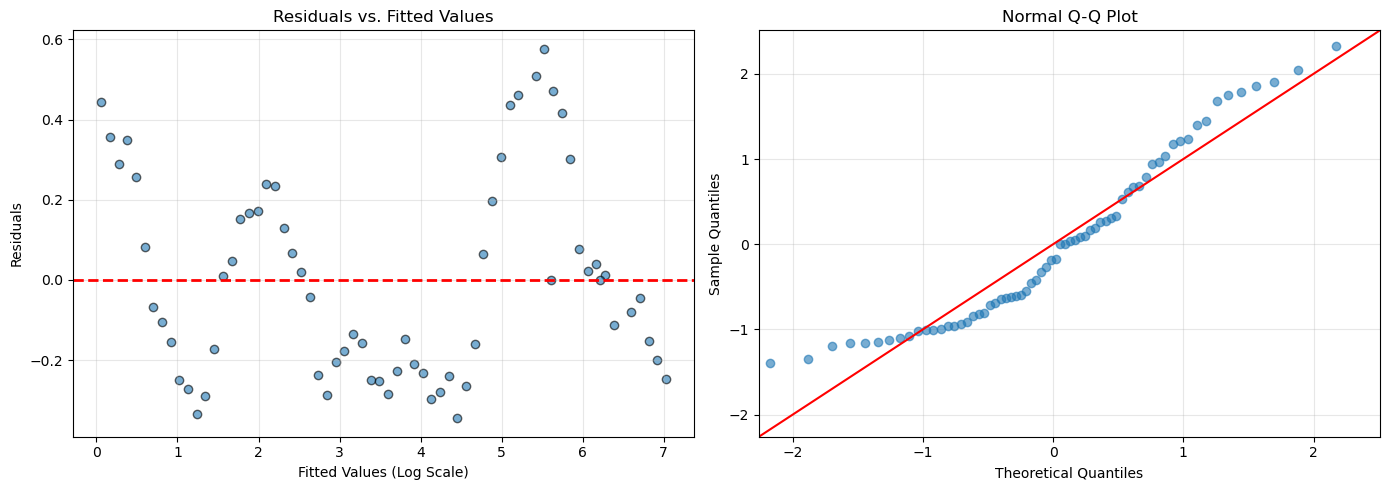

In [12]:
import matplotlib.pyplot as plt

# extracting fitted values (predictions) and residuals (errors)
fitted_values = model1.fittedvalues
residuals = model1.resid 

# set-up
fig, axes = plt.subplots(1,2,figsize=(14,5))

# 3. Residuals vs. Fitted plot for linearity
axes[0].scatter(fitted_values, residuals, alpha=0.6, edgecolors='k')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Residuals vs. Fitted Values')
axes[0].set_xlabel('Fitted Values (Log Scale)')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, alpha=0.3)

# 4. Q-Q plot for Normality
sm.qqplot(residuals, line='45', fit=True, ax=axes[1], alpha=0.6)
axes[1].set_title('Normal Q-Q Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

NOTE ON THE RESIDUAL VS. FITTED VALUES PLOT FOR LINEARITY:
1. The errors are clearly not independent. The Ljung-Box test and the Durbin-Watson test also flagged this previously.
2. The error terms are following a sinusoidal wave. This means that the model is failimg to account for major cycles.
3. The log-linear trend is just a straight line, so it cuts through the waves; it doesn't follow the pattern at all actually.
4. Thus, it can be concluded thta the log-linear model gives a good baseline growth rate to work on, but the ARIMA model is necessary to handle the autocorrelated, cyclical behaviour that the OLS fails to capture.

NOTE ON THE Q-Q PLOT FOR NORMALITY:
Since the blue scattered points are very close to the red line, we can assume that the data is fairly normal in nature.

In [13]:
# WALK-FORWARD BACKTESTING
# we're using this to check whether our prediction for 2030 is even reliable or not
# we'll split the data into sequential data and testing data, then optimize on a pre-decided window, and then check
# we'll calculate the MAPE

In [14]:
from sklearn.metrics import mean_absolute_percentage_error
print("WALK-FORWARD BACKTESTING")

# historical cuttoffs
# we'll do the following: train upto 2010, predict 2011-2015; predict upto 2015, predict 2016-2019
cutoffs = [2010, 2015, 2019]
forecast_horizon = 4 # aage 4 saal ka predict karenge bas 

MAPEs = [] # yahan store karenge  MAPE = mean absolute percentage error

for i in cutoffs:
    # STEP1: split the data
    train_mask = years <= i
    test_mask = (years > i) & (years <= i + forecast_horizon)

    X_train = X[train_mask]
    Y_train_log = Y_log[train_mask]

    X_test = X[test_mask]
    Y_test_log = Y_log[test_mask]

    # enough test data hai bhi ya nahi? checking here
    if len(X_test) == 0:
        continue 

    # STEP2: fit the model only on the training window 
    rolling_model = sm.OLS(Y_train_log, X_train).fit()

    # STEP3: predicting our pre-decided window
    pred_log = rolling_model.predict(X_test)

    # STEP4: converting everything back to absolute values 
    pred_billions = np.exp(pred_log)
    actual_billions = np.exp(Y_test_log)

    # STEP5: calculating the MAPE
    mape = mean_absolute_percentage_error(actual_billions, pred_billions)
    MAPEs.append(mape)

print(f"Average Out-of-Sample Error (MAPE) : {np.mean(MAPEs)}")   


WALK-FORWARD BACKTESTING
Average Out-of-Sample Error (MAPE) : 0.2379738674572689


In [15]:
#putting lichrally everything inside a loop so that we can get all the data for all the countries
import warnings

# suppress messy data warnings to keep the output clean
warnings.filterwarnings('ignore')

# Step1: setup the parameters for the loop
years_str = [col for col in df.columns if col.isnumeric()]
cutoffs = [2010, 2015, 2019]
forecast_horizon = 4

master_results = []


# Step2: iterate through every country in the dataset
for index, row in df.iterrows():
    country_name = row['Country Name']
    
    # extract and clean the time series
    ts_data = row[years_str].astype(float)
    ts_clean = ts_data.interpolate(method='linear').bfill().ffill()
    
    # failsafe: skipping countries with entirely missing data or fewer than 20 data points warna loop crash ho jayega na
    if ts_clean.isna().all() or len(ts_clean.dropna()) < 20:
        continue
        
    years = ts_clean.index.astype(int).values
    exports_billions = ts_clean.values / 1e9
    
    # failsafe: skip if exports are zero or negative (cant take the log warna)
    if (exports_billions <= 0).any():
        continue
        
    Y_log = np.log(exports_billions)
    
    # Build structural matrix
    dummy_2020 = (years == 2020).astype(int)
    dummy_2009 = (years == 2009).astype(int)
    X = np.column_stack([years, dummy_2020, dummy_2009])
    X = sm.add_constant(X)
    
    try:
        # Fit the full historical model for summary stats
        full_model = sm.OLS(Y_log, X).fit()
        r_squared = full_model.rsquared

        # diagnostic testing 
        # run Ljung-Box Test for autocorrelation (Lag 5)
        lb_test = acorr_ljungbox(full_model.resid, lags=[5], return_df=True)
        lb_pvalue = lb_test['lb_pvalue'].iloc[0]

        # run the dw_stat
        dw_stat = durbin_watson(full_model.resid)

        # run the breusch-pagan test
        bp_test = het_breuschpagan(full_model.resid, X)
        bp_pvalue = bp_test[1]
        
        # Walk-Forward Backtesting
        MAPEs = []
        for i in cutoffs:
            train_mask = years <= i
            test_mask = (years > i) & (years <= i + forecast_horizon)
            
            X_train, y_train_log = X[train_mask], Y_log[train_mask]
            X_test, y_test_log = X[test_mask], Y_log[test_mask]
            
            # Failsafe: Skip if there isn't enough training or testing data for the split
            if len(X_test) == 0 or len(X_train) < 10:
                continue
                
            rolling_model = sm.OLS(y_train_log, X_train).fit()
            pred_log = rolling_model.predict(X_test)
            
            pred_billions = np.exp(pred_log)
            actual_billions = np.exp(y_test_log)
            
            mape = mean_absolute_percentage_error(actual_billions, pred_billions)
            MAPEs.append(mape)
            
        avg_mape = np.mean(MAPEs) if MAPEs else np.nan
        
        # Forecast 2030 using the full model
        X_2030 = [1, 2030, 0, 0]
        pred_2030_log = full_model.predict(X_2030)[0]
        pred_2030_billions = np.exp(pred_2030_log)
        
        # Store results
        master_results.append({
            'Country Name': country_name,
            'R-Squared': r_squared,
            'Ljung-Box p-value': lb_pvalue,
            'Durbin-Watson': dw_stat,
            'Breusch-Pagan p-value': bp_pvalue,
            'Average OOS Error (MAPE)': avg_mape,
            'Forecast 2030 ($B)': pred_2030_billions
        })
        
    except Exception as e:
        print(f"{country_name}: {e}")

# 3. Convert the results dictionary into a clean Pandas DataFrame
results_df = pd.DataFrame(master_results)

# 4. Sort the table to see the best performing models first
results_df = results_df.sort_values(by='Average OOS Error (MAPE)')

print("\nPipeline Complete !!!!")

#print(results_df.head())
print("Number of successful models:", len(master_results))
#print(results_df.columns.tolist())
print(results_df)


Pipeline Complete !!!!
Number of successful models: 237
             Country Name  R-Squared  Ljung-Box p-value  Durbin-Watson  \
153               Nigeria       -inf       5.119119e-53       0.000003   
46         Cayman Islands   0.269700       3.697931e-11       0.345310   
202              Eswatini   0.200919       1.710071e-11       0.314610   
24                Bermuda   0.219991       2.698195e-12       0.188286   
185               Senegal   0.955653       1.207742e-29       0.285779   
..                    ...        ...                ...            ...   
123               Lesotho   0.878269       7.521420e-48       0.092735   
184                 Sudan   0.505226       2.558302e-19       0.406968   
29               Botswana   0.869493       3.368761e-43       0.087405   
111           Korea, Rep.   0.910393       1.591842e-42       0.077147   
204  Syrian Arab Republic   0.512472       1.423387e-30       0.235427   

     Breusch-Pagan p-value  Average OOS Error (MAPE)  

ARIMA MODEL

In [16]:
!pip install pmdarima

In [17]:
# importing libraries for ARIMA
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

# just rewriting the set-up for ease
country_name = input("Enter the Country Name to forecast: ")
country_data = df[df['Country Name'] == country_name].squeeze()

years_str = [col for col in df.columns if col.isnumeric()]
ts_data = country_data[years_str].astype(float)
ts_clean = ts_data.interpolate(method='linear').bfill().ffill()

years = ts_clean.index.astype(int).values
exports_billions = ts_clean.values / 1e9
y_log = np.log(exports_billions)



Enter the Country Name to forecast:  India


In [18]:
# 1. STATIONARITY CHECK 
# doing augmented dickey-fuller test (ADF test)
# H0: data is not stationary ( unit root is present)
# H1: data is stationary (unit root is absent)
# we just did stationarity in class grl : mean and variance are constant over time
adf_test = adfuller(Y_log)
print(f"ADF test results' p-value is as follows--- {adf_test[1]}")

# hypothesis testing
if adf_test[1] < 0.05:
    print("REJECT H0. DATA IS STATIONARY")
else:
    print("FTR H0. DATA MAY NOT BE STATIONARY")

ADF test results' p-value is as follows--- 0.8254995180119136
FTR H0. DATA MAY NOT BE STATIONARY


NOTE ON THE DATA NOT BEING STATIONARY:
If the export data were already stationary, a simple ARMA (AutoRegressive Moving Average) model would be fine. However, because this test formally proves the data is non-stationary, it mathematically justifies the "I" (Integrated) part of the ARIMA model.
In the ARIMA parameters of (p,d,q), we need to make sure that d>0.

In [19]:
# Auto-ARIMA Grid Search
# auto-arima grid search is an automated optimization process used to discover the best hyper-parameters (p,d,q)
# for a ts model by evaluating multiple parameter combos against an info criterion like AIC or BIC 
# lowest AIC wins

In [20]:
auto_model = pm.auto_arima(Y_log, 
                            seasonal = False,
                            stepwise = True,
                            suppress_warnings = True, 
                            error_action = "ignore",
                            trace=True)  
# trace=True will let us watch the process of thinking

optimal_order = auto_model.order
print(f"\nWinning ARIMA Order for {country_name}: {optimal_order}")

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-22.092, Time=0.52 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-19.554, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-17.627, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-17.730, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-20.033, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.41 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=-22.760, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.31 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=-22.211, Time=0.07 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-20.865, Time=0.26 sec
 ARIMA(3,1,0)(0,0,0)[0] intercept   : AIC=-22.497, Time=0.12 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-18.966, Time=0.31 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=-20.781, Time=0.09 sec

Best model:  ARIMA(2,1,1)(0,0,0)[0] intercept
Total fit time: 2.491 seconds

Winning ARIMA Order for India: (2, 1, 1)


In [21]:
# p = 2 = autoregression
# d = 1 = differencing
# q = 1 = moving average
# finding the optimal model 
arima_model= sm.tsa.ARIMA(Y_log, order = optimal_order).fit() # fitting
summary_arima_model = arima_model.summary()
print(summary_arima_model)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   66
Model:                 ARIMA(2, 1, 1)   Log Likelihood                  14.390
Date:                Wed, 12 Aug 2026   AIC                            -20.781
Time:                        16:36:54   BIC                            -12.083
Sample:                             0   HQIC                           -17.349
                                 - 66                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3818      0.458      0.834      0.404      -0.515       1.279
ar.L2         -0.3061      0.235     -1.300      0.194      -0.768       0.155
ma.L1         -0.3436      0.476     -0.721      0.4

In [22]:
# ARIMA RESIDUAL DIAGNOSTICS
# we'll check via the lb-test whether the autocorrelation issue has been solved or not
arima_lb_test = acorr_ljungbox(arima_model.resid, lags=[5], return_df=True)
print(f"Ljung-Box p-value (Lag 5): {arima_lb_test['lb_pvalue'].iloc[0]}")

# hypothesis testing
if arima_lb_test['lb_pvalue'].iloc[0] > 0.05:
    print("SUCCESS: p-value > 0.05. Residuals are independent (Autocorrelation is fixed!)")
else:
    print("WARNING: p-value < 0.05. Some autocorrelation remains.")

Ljung-Box p-value (Lag 5): 0.9213453073974947
SUCCESS: p-value > 0.05. Residuals are independent (Autocorrelation is fixed!)


In [23]:
# autocorrelation issue gone!!

In [24]:
# FORECASTING 2030 + CIs
# how many steps ahead 2030 is from our last historical year
last_year = 2023
steps_ahead = 2030 - last_year # 7 steps ahead

# getting the forecast object which contains both predictions and CIs
forecast_obj = arima_model.get_forecast(steps=steps_ahead)

# extracting the log values for 2030
pred_2030_log = forecast_obj.predicted_mean[-1]
conf_int_2030_log = forecast_obj.conf_int(alpha=0.05)[-1]

# back to absolute billions
pred_2030_billions = np.exp(pred_2030_log)
ci_lower_billions = np.exp(conf_int_2030_log[0])
ci_upper_billions = np.exp(conf_int_2030_log[1])

print(f"Projected 2030 Exports: ${pred_2030_billions} Billion")
print(f"95% Confidence Interval: ${ci_lower_billions}B --- ${ci_upper_billions}B")

Projected 2030 Exports: $7.142180381791893 Billion
95% Confidence Interval: $3.1891808983796017B --- $15.994934822283412B


In [25]:
# walk-forward backward testing lessgooo
# 1. rewriting the core variables
country_name = input("Enter the Country Name to forecast: ")
country_data = df[df['Country Name'] == country_name].squeeze()

years_str = [col for col in df.columns if col.isnumeric()]
ts_data = country_data[years_str].astype(float)
ts_clean = ts_data.interpolate(method='linear').bfill().ffill()

years = ts_clean.index.astype(int).values
exports_billions = ts_clean.values / 1e9
Y_log = np.log(exports_billions)

cutoffs = [2010, 2015, 2019]
forecast_horizon = 4
arima_mapes = []

for i in cutoffs:
    train_mask = years <= i
    test_mask = (years > i) & (years <= i + forecast_horizon)
    
    Y_train_log = Y_log[train_mask]
    Y_test_log = Y_log[test_mask]
    
    if len(Y_test_log) == 0:
        continue
        
    # fitting ARIMA on the training window using the optimal order
    rolling_arima = sm.tsa.ARIMA(Y_train_log, order=optimal_order).fit()
    
    # forecasting teh exact number of steps in the test window
    steps_forward = len(Y_test_log)
    pred_log_arima = rolling_arima.forecast(steps=steps_forward)
    
    # convert and calculate MAPE
    pred_billions = np.exp(pred_log_arima)
    actual_billions = np.exp(Y_test_log)
    
    mape = mean_absolute_percentage_error(actual_billions, pred_billions)
    arima_mapes.append(mape)
    
    print(f"Window {i+1}-{i+forecast_horizon} Error: {mape}")

print(f"\nFinal Average Out-of-Sample Error (ARIMA): {np.mean(arima_mapes)}")

Enter the Country Name to forecast:  India


Window 2011-2014 Error: 0.3027940143815674
Window 2016-2019 Error: 0.21181334320379436
Window 2020-2023 Error: 0.13144174402198994

Final Average Out-of-Sample Error (ARIMA): 0.21534970053578392


NOTE:
- Average OOS Error in OLS was ~23%.
- Average OOS Error in ARIMA is ~21%.
- Also, as per the trend :
-- Window 2011-2014 Error: 0.3027940143815674
-- Window 2016-2019 Error: 0.21181334320379436
-- Window 2020-2023 Error: 0.13144174402198994
- This implies that as the model absorbed more historical data, its predictive accuracy massively improved.


In [26]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_percentage_error
import pmdarima as pm
import warnings

# ignore all warnings
warnings.filterwarnings('ignore')

years_str = [col for col in df.columns if col.isnumeric()]
cutoffs = [2010, 2015, 2019]
forecast_horizon = 4

master_results = []

print("OLS vs ARIMA across all countries")

for index, row in df.iterrows():
    country_name = row['Country Name']
    country_code = row.get('Country Code', 'N/A')
    
    ts_data = row[years_str].astype(float)
    ts_clean = ts_data.interpolate(method='linear').bfill().ffill()
    
    # skip bad data
    if ts_clean.isna().all() or len(ts_clean.dropna()) < 20:
        continue
        
    years = ts_clean.index.astype(int).values
    exports_billions = ts_clean.values / 1e9
    
    if (exports_billions <= 0).any():
        continue
        
    y_log = np.log(exports_billions)
    
    # OLS 
    dummy_2020 = (years == 2020).astype(int)
    dummy_2009 = (years == 2009).astype(int)
    X = np.column_stack([years, dummy_2020, dummy_2009])
    X = sm.add_constant(X)
    
    try:
        ols_mapes = []
        for cutoff in cutoffs:
            train_mask = years <= cutoff
            test_mask = (years > cutoff) & (years <= cutoff + forecast_horizon)
            if len(y_log[test_mask]) == 0 or len(y_log[train_mask]) < 10:
                continue
            
            rolling_ols = sm.OLS(y_log[train_mask], X[train_mask]).fit()
            pred_log_ols = rolling_ols.predict(X[test_mask])
            ols_mapes.append(mean_absolute_percentage_error(np.exp(y_log[test_mask]), np.exp(pred_log_ols)))
            
        ols_avg_mape = np.mean(ols_mapes) if ols_mapes else np.nan
        
        # ARIMA
        auto_model = pm.auto_arima(y_log, seasonal=False, stepwise=True, suppress_warnings=True, error_action="ignore")
        arima_order = auto_model.order
        
        # forecast 2030
        arima_full = sm.tsa.ARIMA(y_log, order=arima_order).fit()
        
        # just to be sure
        steps_to_2030 = int(2030 - years[-1])
        
        if steps_to_2030 > 0:
            forecast_obj = arima_full.get_forecast(steps=steps_to_2030)
            arima_2030_pred_billions = np.exp(forecast_obj.predicted_mean[-1])
            arima_2030_ci_lower = np.exp(forecast_obj.conf_int(alpha=0.05)[-1][0])
            arima_2030_ci_upper = np.exp(forecast_obj.conf_int(alpha=0.05)[-1][1])
        else:
            arima_2030_pred_billions = np.nan
            arima_2030_ci_lower = np.nan
            arima_2030_ci_upper = np.nan
        
        # Walk-Forward Backtesting for ARIMA
        arima_mapes = []
        for cutoff in cutoffs:
            train_mask = years <= cutoff
            test_mask = (years > cutoff) & (years <= cutoff + forecast_horizon)
            
            if len(y_log[test_mask]) == 0 or len(y_log[train_mask]) < 10:
                continue
                
            try:
                rolling_arima = sm.tsa.ARIMA(y_log[train_mask], order=arima_order).fit()
                
                # again, just making sure
                steps_forward = int(len(y_log[test_mask]))
                
                pred_log_arima = rolling_arima.forecast(steps=steps_forward)
                arima_mapes.append(mean_absolute_percentage_error(np.exp(y_log[test_mask]), np.exp(pred_log_arima)))
            except:
                continue
                
        arima_avg_mape = np.mean(arima_mapes) if arima_mapes else np.nan
        
        # final master results
        master_results.append({
            'Country Name': country_name,
            'Country Code': country_code,
            'ARIMA Order': str(arima_order),
            'OLS MAPE': ols_avg_mape,
            'ARIMA MAPE': arima_avg_mape,
            'ARIMA Forecast 2030 ($B)': arima_2030_pred_billions,
            'ARIMA 2030 CI Lower': arima_2030_ci_lower,
            'ARIMA 2030 CI Upper': arima_2030_ci_upper
        })
        
    except Exception as e:
        print(f"Failed on {country_name}: {type(e).__name__} - {e}")
        continue

# final comparison df
results_df = pd.DataFrame(master_results)

if not results_df.empty:
    # calculate the direct performance gap
    results_df['MAPE Difference (OLS - ARIMA)'] = results_df['OLS MAPE'] - results_df['ARIMA MAPE']
    print("\nPipeline Complete. Head of unified results:")
    display(results_df[['Country Name', 'ARIMA Order', 'OLS MAPE', 'ARIMA MAPE', 'MAPE Difference (OLS - ARIMA)']].head())
else:
    print("Error: The master results table is completely empty. No countries processed.")

OLS vs ARIMA across all countries

Pipeline Complete. Head of unified results:


,Country Name,ARIMA Order,OLS MAPE,ARIMA MAPE,MAPE Difference (OLS - ARIMA)
0,Aruba,"(0, 1, 0)",0.257153,0.202106,0.055046
1,Africa Eastern and Southern,"(1, 1, 1)",0.370163,0.151862,0.218301
2,Afghanistan,"(0, 2, 3)",0.955591,0.057873,0.897719
3,Angola,"(0, 1, 2)",0.438734,0.373566,0.065167
4,Albania,"(0, 1, 2)",0.624837,0.232445,0.392392


In [27]:
# macro-merge
# emerging vs developed countries comparision with the two models
# the main question we'll answer: Do volatile emerging markets require different forecasting models than stable developed markets?

In [28]:
# loading the wb metadata file
metadata_df = pd.read_csv(r"C:\Users\Kanak Nath\Downloads\API_NE.EXP.GNFS.CD_DS2_en_csv_v2_35140\Metadata_Country_API_NE.EXP.GNFS.CD_DS2_en_csv_v2_35140.csv")
# Select 'TableName' (which holds the country names in the metadata file) instead of 'Country Code'
meta_subset = metadata_df[['TableName', 'Region', 'IncomeGroup']]
# Rename 'TableName' to 'Country Name' so the two datasets have an identical column to lock onto
meta_subset = meta_subset.rename(columns={'TableName': 'Country Name'})
# Merge using Country Name
macro_df = pd.merge(results_df, meta_subset, on='Country Name', how='left')
# Drop the aggregate zones (which have no Region/IncomeGroup)
macro_df = macro_df.dropna(subset=['Region', 'IncomeGroup'])
print("Merge successful. Total countries remaining:", len(macro_df))
#display(macro_df.head())

Merge successful. Total countries remaining: 188


In [29]:
# calculating the overall algorithmic win rate
arima_wins = (macro_df['MAPE Difference (OLS - ARIMA)'] > 0).sum()  # OLS ka MAPE, ARIMA ke MAPE se bada hai 
total_countries = len(macro_df)
win_rate = arima_wins/total_countries
#print(win_rate)
print("OVERALL PERFORMANCE")
print(f"ARIMA outperformed OLS in {arima_wins} out of {total_countries} actual countries/economies ({win_rate} win rate)")

OVERALL PERFORMANCE
ARIMA outperformed OLS in 168 out of 188 actual countries/economies (0.8936170212765957 win rate)


In [30]:
# we'll not check the significance of this 89.36% success rate just to be sure
# we'll do the Wilcoxon Signed-Rank Test
# checks whether the median difference between paired observations is zero or not
# used when data is not normally distributed (ARIMA to waise bhi log mein liya hai humne)
# so it's actually an alternative to t-test
# H0: median is zero (no significant difference)
# H1: median is NOT zero (significant difference)

In [31]:
# now onto teh actual test grlll
from scipy.stats import wilcoxon
stat, p_value = wilcoxon(macro_df['OLS MAPE'], macro_df['ARIMA MAPE'])
print(stat, p_value)

# hypothesis testing 
print("HYPOTHESIS TESTING")
print(f"Wilcoxon p-value: {p_value}")
if p_value < 0.001:   # 99% significant testing hori bahut bhayankar
    print(" Reject H0. ARIMA's advantage is statistically significant (p < 0.001), not just descriptively more common.")
else:
    print(f"Failed to reject H0. ARIMA's advantage is significant at the p = {p_value} level.")

514.0 3.982690603745158e-29
HYPOTHESIS TESTING
Wilcoxon p-value: 3.982690603745158e-29
 Reject H0. ARIMA's advantage is statistically significant (p < 0.001), not just descriptively more common.


In [32]:
# grouping by Income Level
income_comparison = macro_df.groupby('IncomeGroup')[['OLS MAPE', 'ARIMA MAPE']].mean() # SQL onlii
income_comparison['Advantage Margin'] = income_comparison['OLS MAPE'] - income_comparison['ARIMA MAPE']  

# sort in asc order to get where advantage is max
income_comparison = income_comparison.sort_values(by='Advantage Margin', ascending=False)

print("AVERAGE ERROR RATE BY INCOME GROUP")
display(income_comparison)

AVERAGE ERROR RATE BY INCOME GROUP


,OLS MAPE,ARIMA MAPE,Advantage Margin
IncomeGroup,,,
Low income,0.926601,0.427090,0.499511
High income,0.656031,0.187311,0.468719
Upper middle income,0.663530,0.216874,0.446657
Lower middle income,0.559518,0.215030,0.344488


In [33]:
# the advantage margin is positive for EVERY grp and overwhelmingly so
# this just shows that ARIMA works best for low income countries 

# OLS fails miserably for low income countries
# ARIMA MAPE is the lowest for high income countries

In [34]:
# top 5 fastest frowing economies by 2030 (based on ARIMA)

# simpler growth calculation using known 2023 values directly from the original df
# extract 2023 values from the original df and map them
df_2023 = df[['Country Name', '2023']].copy()
df_2023['2023_Billions'] = df_2023['2023'].astype(float) / 1e9
macro_df = pd.merge(macro_df, df_2023[['Country Name', '2023_Billions']], on='Country Name', how='left')

macro_df['2030 Growth (%)'] = ((macro_df['ARIMA Forecast 2030 ($B)'] - macro_df['2023_Billions']) / macro_df['2023_Billions']) * 100

print("TOP 5 FASTEST GROWING ECONOMIES BY 2030")
display(macro_df.sort_values(by='2030 Growth (%)', ascending=False)[['Country Name', 'IncomeGroup', '2023_Billions', 'ARIMA Forecast 2030 ($B)', '2030 Growth (%)']].head())

TOP 5 FASTEST GROWING ECONOMIES BY 2030


,Country Name,IncomeGroup,2023_Billions,ARIMA Forecast 2030 ($B),2030 Growth (%)
34,"Congo, Dem. Rep.",Low income,29.372039,95.392009,224.771487
6,Armenia,Upper middle income,14.755464,42.669590,189.178237
179,Uzbekistan,Lower middle income,25.070062,71.093823,183.580559
54,Ethiopia,Low income,8.962144,24.840686,177.173467
183,Kosovo,Upper middle income,4.149071,10.848711,161.473256


NOTE:
- ARIMA assumes these current trends will continue uninterrupted.
- Just because the answer seems weird doesn't mean it's inaccurate.
- The model doesn't know geopolitics, so according to the model, the result isn't surprising (although it's surprising to me lol).

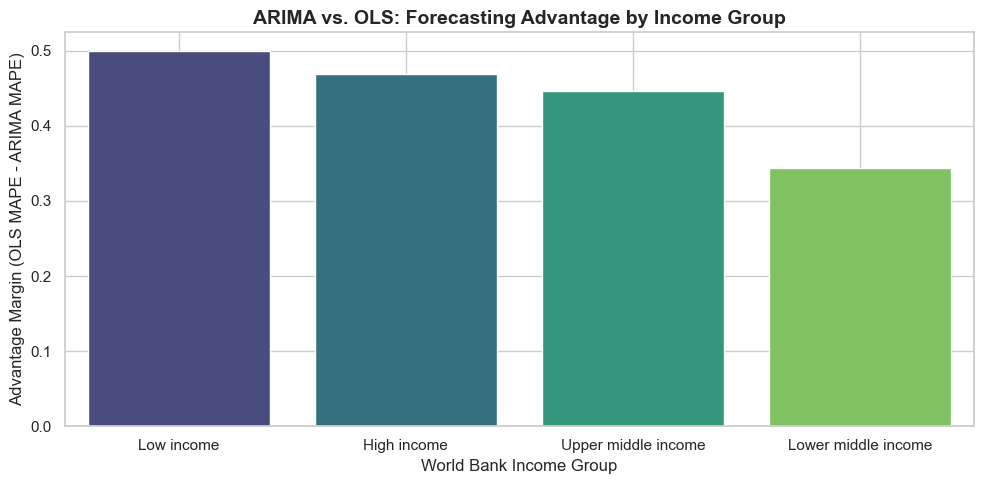

In [35]:
# final lap: visual representation
# first, we'll show that ARIMA > OLS in low-income countries
# bas OLS MAPE-ARIMA MAPE wala column print karna hai

# setting a theme 
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,5))
sns.barplot(
    x=income_comparison.index, 
    y=income_comparison['Advantage Margin'], 
    palette="viridis"
)
plt.title("ARIMA vs. OLS: Forecasting Advantage by Income Group", fontsize=14, fontweight='bold')
plt.xlabel("World Bank Income Group", fontsize=12)
plt.ylabel("Advantage Margin (OLS MAPE - ARIMA MAPE)", fontsize=12)
plt.tight_layout()
plt.grid(True)
plt.show()

TOP 5 FASTEST GROWING ECONOMIES WITH 95% CONFIDENCE INTERVALS


,Country Name,IncomeGroup,2023_Billions,ARIMA Forecast 2030 ($B),2030 Growth (%),2030 CI Lower (%),2030 CI Upper (%)
34,"Congo, Dem. Rep.",Low income,29.372039,95.392009,224.771487,0.541260,949.086906
6,Armenia,Upper middle income,14.755464,42.669590,189.178237,2.092453,719.101221
179,Uzbekistan,Lower middle income,25.070062,71.093823,183.580559,36.436508,489.416531
54,Ethiopia,Low income,8.962144,24.840686,177.173467,95.376466,293.215890
183,Kosovo,Upper middle income,4.149071,10.848711,161.473256,87.551349,264.530908


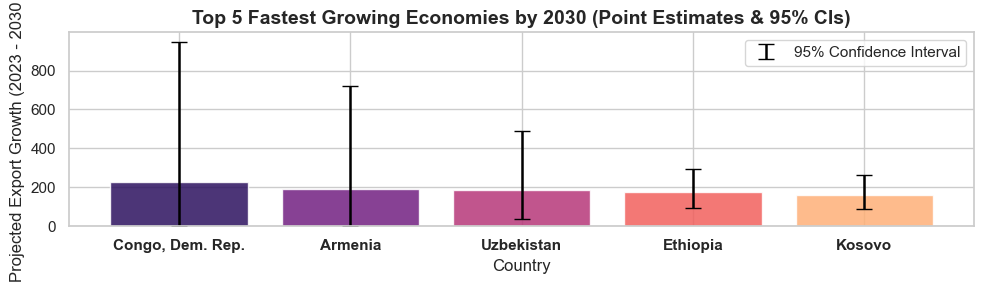

In [36]:
# next, we'll simply print the top 5 economies (2030 projections)

# calculate CIs first. ( taaki pta chale significant hai bhi ya nahi?
macro_df['2030 CI Lower (%)'] = ((macro_df['ARIMA 2030 CI Lower'] - macro_df['2023_Billions']) / macro_df['2023_Billions']) * 100
macro_df['2030 CI Upper (%)'] = ((macro_df['ARIMA 2030 CI Upper'] - macro_df['2023_Billions']) / macro_df['2023_Billions']) * 100

# main meat of the graph duh
top_5_growth = macro_df.sort_values(by='2030 Growth (%)', ascending=False).head(5)

print("TOP 5 FASTEST GROWING ECONOMIES WITH 95% CONFIDENCE INTERVALS")
display(top_5_growth[[
    'Country Name', 
    'IncomeGroup', 
    '2023_Billions', 
    'ARIMA Forecast 2030 ($B)', 
    '2030 Growth (%)', 
    '2030 CI Lower (%)', 
    '2030 CI Upper (%)'
]])

# finally plotting
plt.figure(figsize=(10, 3))
sns.set_theme(style="whitegrid")

# calculating asymmetric error bounds relative to the point estimate
# ARIMA mein log use kiya na, to bell-shaped curve  kaam nahi aayega CIs mein _____________ # RE-CHECK AND PRACTISE AGAIN
lower_err = top_5_growth['2030 Growth (%)'] - top_5_growth['2030 CI Lower (%)']
upper_err = top_5_growth['2030 CI Upper (%)'] - top_5_growth['2030 Growth (%)']
asymmetric_yerr = [lower_err, upper_err]   # python syntax ke liye likhna padta hai yaar

x_coords = np.arange(len(top_5_growth))
plt.bar(x_coords, top_5_growth['2030 Growth (%)'], color=sns.color_palette("magma", 5), alpha=0.85)

# adding standard error bars to the main graph ( significance bhi to show karna hai naaa)
plt.errorbar(
    x=x_coords, 
    y=top_5_growth['2030 Growth (%)'], 
    yerr=asymmetric_yerr, 
    fmt='none', 
    ecolor='black', 
    capsize=6, 
    linewidth=1.8,
    label='95% Confidence Interval'
)

plt.xticks(x_coords, top_5_growth['Country Name'], fontsize=11, fontweight='bold')
plt.title("Top 5 Fastest Growing Economies by 2030 (Point Estimates & 95% CIs)", fontsize=14, fontweight='bold')
plt.xlabel("Country", fontsize=12)
plt.ylabel("Projected Export Growth (2023 - 2030 %)", fontsize=12)
plt.legend(loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
# congo is highly uncertain
# ethiopio and kosovo are alright
# even uzbekistan to an extent is fine 
# but congo is extremely uncertain, the growth projections for congo CANNOT be trusted 
# armenia isn't okay either

In [38]:
# ARIMAX now
# for that, we also need an X, which we're taking as GDP (current USD)

In [45]:
import pandas as pd
import numpy as np

# load data files
exports_df = pd.read_csv(r"C:\Users\Kanak Nath\Downloads\wb_exportdata_2025.csv")
gdp_df = pd.read_csv(r"C:\Users\Kanak Nath\Downloads\API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234\API_NY.GDP.MKTP.CD_DS2_en_csv_v2_234.csv")

# find ONLY the common year columns between both files
exports_years = [col for col in exports_df.columns if str(col).isnumeric() and len(str(col)) == 4]
gdp_years = [col for col in gdp_df.columns if str(col).isnumeric() and len(str(col)) == 4]

# prevents crashing 2025/2023 thing
common_years_str = sorted(list(set(exports_years).intersection(set(gdp_years))))

# dynamically align the ID columns
possible_id_vars = ['Country Name', 'Country Code']
common_id_vars = [col for col in possible_id_vars if col in exports_df.columns and col in gdp_df.columns]

# clean melt function using the safe common years
def melt_and_clean(df, id_vars, value_name):
    melted = df.melt(
        id_vars=id_vars,
        value_vars=common_years_str,
        var_name='Year',
        value_name=value_name
    )
    # Convert years to integers
    melted['Year'] = melted['Year'].astype(int)
    # Convert data to billions
    melted[value_name] = pd.to_numeric(melted[value_name], errors='coerce') / 1e9
    return melted

# melt and Merge
exports_long = melt_and_clean(exports_df, common_id_vars, 'Exports_Billions')
gdp_long = melt_and_clean(gdp_df, common_id_vars, 'GDP_Billions')

master_ts_df = pd.merge(exports_long, gdp_long, on=common_id_vars + ['Year'], how='inner')
master_ts_df = master_ts_df.sort_values(by=common_id_vars + ['Year']).reset_index(drop=True)

print("Data merged successfully. Preview:")
display(master_ts_df.head())

Data merged successfully. Preview:


,Country Name,Country Code,Year,Exports_Billions,GDP_Billions
0,Afghanistan,AFG,1960,0.022222,NaN
1,Afghanistan,AFG,1961,0.024444,NaN
2,Afghanistan,AFG,1962,0.026667,NaN
3,Afghanistan,AFG,1963,0.068889,NaN
4,Afghanistan,AFG,1964,0.071111,NaN


In [46]:
# now, we'll do granger causaloty test
#  Granger causality test is a statistical hypothesis test for determining whether one time series is useful in forecasting another
# H0: doesn't help predict another (non-causality)
# H1: helps (causality)

In [50]:
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
# checking for one country- India hi sahi

# isolate India and prepare the time series
india_data = master_ts_df[master_ts_df['Country Name'] == 'India'].copy()

# Interpolate any missing values, then drop if still NaN at the edges
india_data['Exports_Billions'] = india_data['Exports_Billions'].interpolate(method='linear').bfill().ffill()
india_data['GDP_Billions'] = india_data['GDP_Billions'].interpolate(method='linear').bfill().ffill()
india_data = india_data.dropna(subset=['Exports_Billions', 'GDP_Billions'])

years = india_data['Year'].values
Y_log = np.log(india_data['Exports_Billions'].values)
X_gdp_log = np.log(india_data['GDP_Billions'].values)

print("STATIONARITY CHECKS:")
# Check stationarity of the new exogenous variable
adf_gdp = adfuller(X_gdp_log)
print("HYPOTHESIS TESTING")
print(f"GDP Log ADF p-value: {adf_gdp[1]:.4f} (If > 0.05, it is non-stationary and needs differencing)")

print("GRANGER CAUSALITY TEST:")
# Does GDP help predict Exports? 
# Note: Granger test expects [Target, Predictor] format
combined_data = np.column_stack([Y_log, X_gdp_log])
# We test up to 3 lags (3 years)
gc_results = grangercausalitytests(combined_data, maxlag=3, verbose=False)
print("HYPOTHESIS TESTING")
for lag in range(1, 4):
    p_val = gc_results[lag][0]['ssr_ftest'][1]
    print(f"Lag {lag} - p-value: {p_val}")
    if p_val < 0.05:
        print(f"  Result: GDP significantly Granger-causes Exports at lag {lag}.")


# if it turns out to be showing causality, onlythen will we be able to go forward with the ARIMAX thing

# just auto-arima with the exog turned on
print("Now, we'll do prototyping for the ARIMAX model")
print("ARIMAX MODEL FITTING ")
# Reshape X for pmdarima
X_exog = X_gdp_log.reshape(-1, 1)

# Find optimal order utilizing the exogenous variable
auto_model_x = pm.auto_arima(
    Y_log, X=X_exog,
    seasonal=False, stepwise=True,
    suppress_warnings=True, error_action="ignore"
)
optimal_order_x = auto_model_x.order
print(f"Optimal ARIMAX Order: {optimal_order_x}")

# Fit the final SARIMAX model
# SARIMAX is just the umbrella term for the ARIMAX code
# if the "seasonal" in SARIMAX is turned off, it is just ARIMAX na!
# just a code syntax thing dw
arimax_model = sm.tsa.SARIMAX(Y_log, exog=X_exog, order=optimal_order_x).fit(disp=False)
print(arimax_model.summary().tables[1])

print("RESIDUAL DIAGNOSTICS")
lb_test_x = acorr_ljungbox(arimax_model.resid, lags=[5], return_df=True)
print(f"Ljung-Box p-value (lag 5): {lb_test_x['lb_pvalue'].iloc[0]}")
print("HYPOTHESIS TESTING")
if lb_test_x['lb_pvalue'].iloc[0] > 0.05:
    print("The model successfully extracted all the 'signal' from both Exports and GDP, and only random 'noise' is left")
else:
    print("Some signal is still left")
    
# The Ljung-Box test checks if there are any remaining predictable patterns left in those errors. If the p-value is above 0.05, it means the model successfully extracted all the "signal" from both Exports and GDP, and only random "noise" is left.

STATIONARITY CHECKS:
HYPOTHESIS TESTING
GDP Log ADF p-value: 0.9594 (If > 0.05, it is non-stationary and needs differencing)
GRANGER CAUSALITY TEST:
HYPOTHESIS TESTING
Lag 1 - p-value: 0.2567151936772717
Lag 2 - p-value: 0.8477228459198811
Lag 3 - p-value: 0.6230089468007483
Now, we'll do prototyping for the ARIMAX model
ARIMAX MODEL FITTING 
Optimal ARIMAX Order: (2, 0, 3)
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.6165      0.044     14.084      0.000       0.531       0.702
ar.L1          1.9949      0.011    182.990      0.000       1.974       2.016
ar.L2         -0.9970      0.011    -92.782      0.000      -1.018      -0.976
ma.L1         -0.8761      0.320     -2.735      0.006      -1.504      -0.248
ma.L2         -0.0426      0.183     -0.233      0.816      -0.401       0.316
ma.L3         -0.0686      0.154     -0.446      0.656      -0.370    

- Now that we know that most of the signal has been extracted with the ARIMAX prototype, we can actually move forward with the ARIMAX implementation.
- However, one big issue is that we cannot predict 2030 exports without knowing 2030 GDP
- So, we'll run a "nested forecast"
- First, we will use a standard ARIMA model to forecast India's GDP forward to 2030.
- Then, we will inject that forecasted GDP directly into the ARIMAX model to generate the final 2030 export projection.

In [52]:
import numpy as np
import pmdarima as pm
import statsmodels.api as sm

# calculate exactly how many years to forecast to reach 2030 jaise pehle kiya tha
last_year = int(years[-1])
steps_to_2030 = 2030 - last_year

print(f"FORECASTING GDP TO 2030 ({steps_to_2030} steps)")

# find the optimal ARIMA order for GDP itself --- last cell mein hi kiya
gdp_auto = pm.auto_arima(X_gdp_log, seasonal=False, stepwise=True, suppress_warnings=True)
print(f"Optimal ARIMA Order for GDP: {gdp_auto.order}")

# fit the GDP model and forecast
gdp_model = sm.tsa.ARIMA(X_gdp_log, order=gdp_auto.order).fit()
gdp_forecast_log = gdp_model.get_forecast(steps=steps_to_2030).predicted_mean

# extract the final GDP value whether it is a pandas Series or numpy array
final_gdp_log = gdp_forecast_log.iloc[-1] if hasattr(gdp_forecast_log, 'iloc') else gdp_forecast_log[-1]
final_gdp = np.exp(final_gdp_log)
print(f"Projected GDP for 2030: ${final_gdp:.2f} Billion\n")

print("FORECASTING EXPORTS TO 2030 USING FUTURE GDP")

# feed the future GDP into the fitted ARIMAX model
future_exog = np.asarray(gdp_forecast_log).reshape(-1, 1)

# generate the ARIMAX forecast using the future GDP
export_forecast_x = arimax_model.get_forecast(steps=steps_to_2030, exog=future_exog)

# extract mean and confidence intervals
pred_mean = export_forecast_x.predicted_mean
pred_2030_log = pred_mean.iloc[-1] if hasattr(pred_mean, 'iloc') else pred_mean[-1]
# CIs kuch to alag hounge, we'll talk about it later

ci = export_forecast_x.conf_int(alpha=0.05)
ci_2030_log = ci.iloc[-1].values if hasattr(ci, 'iloc') else ci[-1]

# convert back from log scale to Billions (USD)
pred_2030_billions_x = np.exp(pred_2030_log)
ci_lower_billions_x = np.exp(ci_2030_log[0])
ci_upper_billions_x = np.exp(ci_2030_log[1])

print(f"ARIMAX 2030 Export Projection: ${pred_2030_billions_x} Billion")
print(f"95% Confidence Interval: [${ci_lower_billions_x}B, ${ci_upper_billions_x}B]")

FORECASTING GDP TO 2030 (5 steps)
Optimal ARIMA Order for GDP: (0, 1, 0)
Projected GDP for 2030: $3956.07 Billion

FORECASTING EXPORTS TO 2030 USING FUTURE GDP
ARIMAX 2030 Export Projection: $877.8625680604054 Billion
95% Confidence Interval: [$585.5402499063566B, $1316.122484363553B]


Note on ARIMAX Uncertainty: 
- Because the 2030 export projection relies on an exogenous regressor (GDP) that must itself be forecasted forward, the reported 95% confidence interval underestimates total real-world variance.
- In a fully rigorous multi-stage setup, forecast error from the GDP equation compounds into the export model, implying a wider true prediction interval

In [53]:
# onto WALK-FORWARD BACKTESTING
# for the historical backtest cutoffs (e.g., 2010, 2015, 2019), we do not forecast GDP
# cuz those past years have already happened, we feed the true, known historical GDP into the model for the test windows
# this ensures we are testing whether GDP actually explains export movements cleanly, without compounding error from a bad GDP guess

In [57]:
from sklearn.metrics import mean_absolute_percentage_error
cutoffs = [2010, 2015, 2019]
forecast_horizon = 4
arimax_mapes = []

# abhi sirf india ke liye karenge
# next mein har country ke liye scale kar denge

print("RUNNING WALK-FORWARD BACKTEST FOR ARIMAX (INDIA)")

for cutoff in cutoffs:
    # create train and test masks based on Year
    train_mask = years <= cutoff
    test_mask = (years > cutoff) & (years <= cutoff + forecast_horizon)
    
    if sum(test_mask) == 0 or sum(train_mask) < 10:
        continue
        
    try:
        # extract training and test slices
        train_y = Y_log[train_mask]
        train_exog = X_gdp_log[train_mask].reshape(-1, 1)
        
        # fit rolling model
        rolling_arimax = sm.tsa.SARIMAX(
            train_y, 
            exog=train_exog, 
            order=optimal_order_x
        ).fit(disp=False)
        
        # use dynamic forecasting with the exact number of steps
        steps = int(sum(test_mask))
        test_exog = X_gdp_log[test_mask].reshape(-1, 1)
        
        forecast_obj = rolling_arimax.get_forecast(steps=steps, exog=test_exog)
        pred_log = forecast_obj.predicted_mean
        
        # compute MAPE on original billions scale
        actual_exports = np.exp(Y_log[test_mask])
        predicted_exports = np.exp(pred_log)
        
        fold_mape = mean_absolute_percentage_error(actual_exports, predicted_exports)
        arimax_mapes.append(fold_mape)
        print(f"Cutoff {cutoff}: Backtest MAPE = {fold_mape*100}%")
        
    except Exception as e:
        print(f"Cutoff {cutoff} failed: {e}")

# Compute average backtest error
avg_arimax_mape = np.mean(arimax_mapes) if arimax_mapes else np.nan
print(f"\nAverage ARIMAX Out-of-Sample MAPE for India: {avg_arimax_mape*100}%")

RUNNING WALK-FORWARD BACKTEST FOR ARIMAX (INDIA)
Cutoff 2010: Backtest MAPE = 6.071810654080282%
Cutoff 2015: Backtest MAPE = 9.286552469771609%
Cutoff 2019: Backtest MAPE = 19.951764733819676%

Average ARIMAX Out-of-Sample MAPE for India: 11.770042619223856%


Interpretation of the outcome:
1. cutoff 2010 - high accuracy
2. cutoff 2015 - good performance still
3. cut off 2019 - big error jump

The reason might be the the covid-19 pandemic and global supply chain shocks.


The 2019 cutoff means the model was trained on pre-2019 data and forced to forecast out to 2023. That exact window includes the 2020 global trade collapse followed by an unprecedented, erratic post-pandemic rebound. No model—whether OLS, ARIMA, or ARIMAX—could easily predict that massive, sudden volatility using only historical trends and GDP paths.

In [58]:
# now, scaling the model for all countries

In [60]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
import pmdarima as pm
from sklearn.metrics import mean_absolute_percentage_error
import warnings

warnings.filterwarnings('ignore')

master_arimax_results = []
countries = master_ts_df['Country Name'].unique()

print(f"--- STARTING GLOBAL ARIMAX PIPELINE ACROSS {len(countries)} COUNTRIES ---")

for idx, country_name in enumerate(countries):
    print(f"[{idx+1}/{len(countries)}] Processing: {country_name}...", end='\r')
    
    # 1. Isolate country slice
    c_data = master_ts_df[master_ts_df['Country Name'] == country_name].copy()
    c_data = c_data.dropna(subset=['Exports_Billions', 'GDP_Billions'])
    
    if len(c_data) < 25:  # Skip countries with sparse historical data
        continue
        
    try:
        years = c_data['Year'].values
        Y_log = np.log(c_data['Exports_Billions'].values)
        X_gdp_log = np.log(c_data['GDP_Billions'].values)
        
        # Check for non-finite values
        if not np.isfinite(Y_log).all() or not np.isfinite(X_gdp_log).all():
            continue
            
        # 2. Find optimal ARIMAX order using GDP as exog
        X_exog = X_gdp_log.reshape(-1, 1)
        auto_model_x = pm.auto_arima(
            Y_log, X=X_exog,
            seasonal=False, stepwise=True,
            suppress_warnings=True, error_action="ignore"
        )
        optimal_order = auto_model_x.order
        
        # 3. Walk-Forward Backtest (using true historical GDP for test windows)
        cutoffs = [2010, 2015, 2019]
        horizon = 4
        backtest_mapes = []
        
        for cutoff in cutoffs:
            train_mask = years <= cutoff
            test_mask = (years > cutoff) & (years <= cutoff + horizon)
            
            if sum(test_mask) == 0 or sum(train_mask) < 10:
                continue
                
            try:
                rolling_model = sm.tsa.SARIMAX(
                    Y_log[train_mask], 
                    exog=X_gdp_log[train_mask].reshape(-1, 1), 
                    order=optimal_order
                ).fit(disp=False)
                
                steps = int(sum(test_mask))
                test_exog = X_gdp_log[test_mask].reshape(-1, 1)
                forecast_obj = rolling_model.get_forecast(steps=steps, exog=test_exog)
                
                actual = np.exp(Y_log[test_mask])
                pred = np.exp(forecast_obj.predicted_mean)
                backtest_mapes.append(mean_absolute_percentage_error(actual, pred))
            except:
                continue
                
        avg_arimax_mape = np.mean(backtest_mapes) if backtest_mapes else np.nan
        
        # 4. Nested 2030 Forecast (Forecasting GDP forward first)
        last_year = int(years[-1])
        steps_to_2030 = 2030 - last_year
        
        if steps_to_2030 > 0:
            # Forecast GDP to 2030
            gdp_auto = pm.auto_arima(X_gdp_log, seasonal=False, stepwise=True, suppress_warnings=True)
            gdp_model = sm.tsa.ARIMA(X_gdp_log, order=gdp_auto.order).fit()
            gdp_forecast_log = gdp_model.get_forecast(steps=steps_to_2030).predicted_mean
            
            # Fit final ARIMAX on full history and predict using future GDP
            final_model = sm.tsa.SARIMAX(
                Y_log, 
                exog=X_exog, 
                order=optimal_order
            ).fit(disp=False)
            
            future_exog = np.asarray(gdp_forecast_log).reshape(-1, 1)
            export_forecast_x = final_model.get_forecast(steps=steps_to_2030, exog=future_exog)
            
            pred_2030_log = export_forecast_x.predicted_mean
            pred_2030_val = pred_2030_log.iloc[-1] if hasattr(pred_2030_log, 'iloc') else pred_2030_log[-1]
            
            ci = export_forecast_x.conf_int(alpha=0.05)
            ci_vals = ci.iloc[-1].values if hasattr(ci, 'iloc') else ci[-1]
            
            forecast_2030 = np.exp(pred_2030_val)
            ci_lower = np.exp(ci_vals[0])
            ci_upper = np.exp(ci_vals[1])
        else:
            forecast_2030, ci_lower, ci_upper = np.nan, np.nan, np.nan
            
        # Store results
        master_arimax_results.append({
            'Country Name': country_name,
            'ARIMAX Order': str(optimal_order),
            'ARIMAX MAPE': avg_arimax_mape,
            'ARIMAX Forecast 2030 ($B)': forecast_2030,
            'ARIMAX CI Lower': ci_lower,
            'ARIMAX CI Upper': ci_upper
        })
        
    except Exception as e:
        continue

# Convert results to DataFrame
arimax_results_df = pd.DataFrame(master_arimax_results)
print("\n\n--- GLOBAL ARIMAX PIPELINE COMPLETE ---")
display(arimax_results_df.head())

# Save to artifacts for merging with your existing results table
arimax_results_df.to_csv('master_arimax_results.csv', index=False)

--- STARTING GLOBAL ARIMAX PIPELINE ACROSS 264 COUNTRIES ---
[264/264] Processing: Zimbabwe......Gaza.........ng high income)...stan (excluding high income)...

--- GLOBAL ARIMAX PIPELINE COMPLETE ---


,Country Name,ARIMAX Order,ARIMAX MAPE,ARIMAX Forecast 2030 ($B),ARIMAX CI Lower,ARIMAX CI Upper
0,Africa Eastern and Southern,"(1, 0, 1)",0.085178,386.846736,267.430782,559.585533
1,Albania,"(1, 0, 0)",0.077747,13.303317,6.164740,28.708145
2,Algeria,"(1, 0, 0)",0.155701,69.495918,28.486075,169.545384
3,Argentina,"(1, 0, 0)",0.130128,97.386661,44.232004,214.418541
4,Armenia,"(2, 0, 0)",0.240839,13.912656,5.357245,36.130885


In [63]:
# this file (and all the subsequent files that we'll save will get saved in the "current working directory"-- which is the exact same folder on my laptop where jupyter nb is running

In [65]:
# just making sure lol
import pandas as pd
df = pd.read_csv('master_arimax_results.csv')
#print(df.head())

In [66]:
# THE THREE-WAY MODEL COMPARISION  
# lessgoooo 

In [69]:
import pandas as pd
import numpy as np

# 1. Load your existing master results and the new ARIMAX results
try:
    existing_results = pd.read_csv('master_forecast_results.csv')
except:
    # If saved under a different variable name, adjust here
    existing_results = results_df.copy() 

arimax_res = pd.read_csv('master_arimax_results.csv')

# 2. Merge them together on Country Name
master_three_way = pd.merge(existing_results, arimax_res, on='Country Name', how='inner')

# Ensure we only compare rows where all three MAPEs are valid numbers
comparison_subset = master_three_way.dropna(subset=['OLS MAPE', 'ARIMA MAPE', 'ARIMAX MAPE']).copy()

# 3. Determine the winning model for each country (lowest MAPE wins)
def get_winner(row):
    mapes = {
        'OLS': row['OLS MAPE'],
        'ARIMA': row['ARIMA MAPE'],
        'ARIMAX': row['ARIMAX MAPE']
    }
    return min(mapes, key=mapes.get)

comparison_subset['Best Model'] = comparison_subset.apply(get_winner, axis=1)

# 4. Calculate global win percentages
win_counts = comparison_subset['Best Model'].value_counts(normalize=True) * 100

print("--- GLOBAL MODEL WIN RATES (OUT-OF-SAMPLE MAPE) ---")
for model, pct in win_counts.items():
    print(f"{model}: {pct:.1f}% of economies")

print(f"\nTotal economies compared: {len(comparison_subset)}")

# Preview the master comparison table
display(comparison_subset[['Country Name', 'OLS MAPE', 'ARIMA MAPE', 'ARIMAX MAPE', 'Best Model']].head(10))

# Save the final three-way table for your Streamlit app and README
comparison_subset.to_csv('master_three_way_results.csv', index=False)

--- GLOBAL MODEL WIN RATES (OUT-OF-SAMPLE MAPE) ---
ARIMAX: 80.0% of economies
ARIMA: 17.1% of economies
OLS: 2.9% of economies

Total economies compared: 205


,Country Name,OLS MAPE,ARIMA MAPE,ARIMAX MAPE,Best Model
0,Aruba,0.257153,0.202106,0.148925,ARIMAX
1,Africa Eastern and Southern,0.370163,0.151862,0.085178,ARIMAX
2,Albania,0.624837,0.232445,0.077747,ARIMAX
3,Argentina,0.649045,0.127753,0.130128,ARIMA
4,Armenia,0.719127,0.356235,0.240839,ARIMAX
5,Australia,0.408465,0.177877,0.067151,ARIMAX
6,Austria,0.716086,0.119480,0.042584,ARIMAX
7,Azerbaijan,0.699307,0.228648,0.187428,ARIMAX
8,Belgium,0.552155,0.136981,0.063883,ARIMAX
9,Benin,0.502681,0.228422,0.237621,ARIMA


In [70]:
# damnnn are u even looking at the win rates???? CRAZY!

In [73]:
# again, just making sure
import pandas as pd
df = pd.read_csv('master_three_way_results.csv')
# print(df.head())

In [75]:
# STREAMLIT APP DEPLOYMENT
# however, the streamlit app must be launched from the laptop terminal or command line, not this nb cell
# so ig i'll take it there and come back after the code